# Perceptron Using sklearn

Weights: [2. 2.]
Bias: -3.0


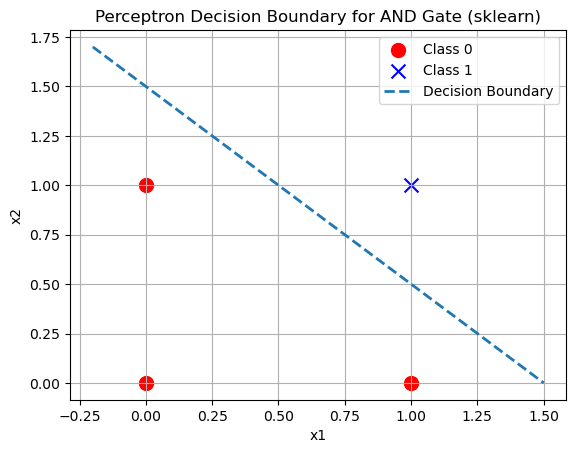

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

# AND gate data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# Train Perceptron model
model = Perceptron(max_iter=1000, tol=1e-3, random_state=42)

# If tol is set to 1e-3 (which equals 0.001), training will stop when 
# the improvement in loss becomes smaller than this value

# random_state is a seed that controls randomness in machine learning models 
# to ensure reproducible results. Setting it guarantees the same data splits 
# or model behavior across runs. 

# random_state=None, the random number generator uses the default state 
# from NumPy, leading to different results on each run. 

# model = Perceptron()

model.fit(X, y)

# Extract learned parameters
w = model.coef_[0]
b = model.intercept_[0]

print("Weights:", w)
print("Bias:", b)


# Plot data points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', s=100, label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', s=100, marker='x', label='Class 1')

# Decision boundary: w1*x1 + w2*x2 + b = 0
x_vals = np.array([-0.2, 1.5])
y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals, '--', linewidth=2, label='Decision Boundary')

# Plot formatting
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary for AND Gate (sklearn)")
plt.legend()
plt.grid(True)
plt.show()


# Perceptron from scratch

Weights: [0.2 0.1]
Bias: -0.20000000000000004


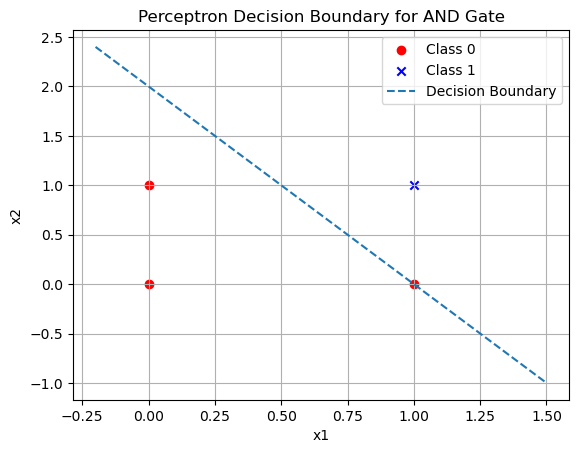

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Training data (AND gate)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# Parameters
lr = 0.1
epochs = 10
weights = np.zeros(X.shape[1])
bias = 0

# Training
for _ in range(epochs):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = 1 if linear_output >= 0 else 0

        # Update rule
        weights += lr * (y[i] - y_pred) * X[i]
        bias += lr * (y[i] - y_pred)

print("Weights:", weights)
print("Bias:", bias)

# ---------------- Visualization ----------------

# Plot data points
for i in range(len(y)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', marker='o', label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', marker='x', label='Class 1')

# Decision boundary: w1*x1 + w2*x2 + b = 0

# x_vals = np.array([-0.25, 1.5])
# y_vals = 1.5 - x_vals

x_vals = np.array([-0.2, 1.5])
y_vals = -(weights[0] * x_vals + bias) / weights[1]

plt.plot(x_vals, y_vals, linestyle='--', label='Decision Boundary')

# Labels and title
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary for AND Gate")
plt.legend()
plt.grid(True)
plt.show()


# Perceptron on iris dataset

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load and split data
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# Initialize and train model
model = Perceptron(random_state=42, max_iter=100, tol=1e-3)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Model predicted [5,6,7,8] as ",model.predict([[5,6,7,8]]))
print("Accuracy:", accuracy_score(y_test, y_pred))   

Model predicted [5,6,7,8] as  [2]
Accuracy: 0.6333333333333333


2D perceptron weights: [-0.1  0. ]
2D perceptron bias: 0.0
Final epoch misclassifications: 4


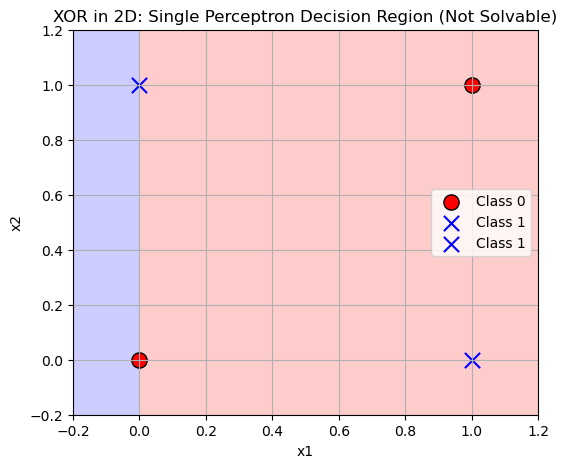

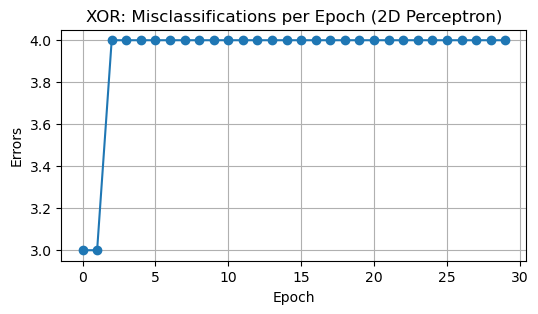

3D-feature perceptron weights: [ 0.1  0.1 -0.3]
3D-feature perceptron bias: -0.1
Predictions with x1*x2 feature: [0 1 1 0]
True labels: [0 1 1 0]


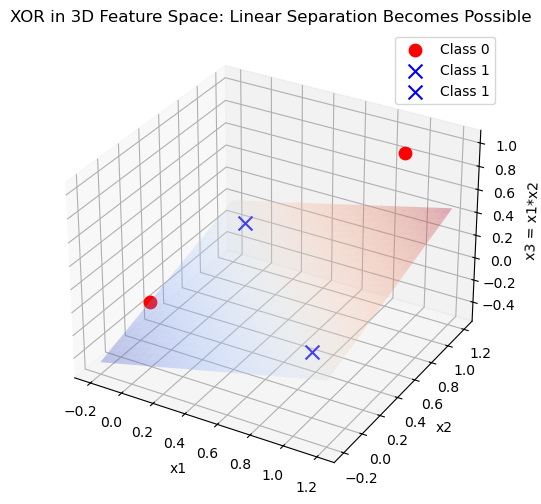

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# XOR data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)
y = np.array([0, 1, 1, 0], dtype=int)

# -------------------------------
# 1) Single perceptron in 2D (will fail on XOR)
# -------------------------------
lr = 0.1
epochs = 30
w = np.zeros(2, dtype=float)
b = 0.0
errors_per_epoch = []

for _ in range(epochs):
    errors = 0
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        y_pred = 1 if z >= 0 else 0
        update = lr * (y[i] - y_pred)
        w += update * X[i]
        b += update
        errors += int(update != 0)
    errors_per_epoch.append(errors)

print("2D perceptron weights:", w)
print("2D perceptron bias:", b)
print("Final epoch misclassifications:", errors_per_epoch[-1])

# 2D decision region
xx = np.linspace(-0.2, 1.2, 300)
yy = np.linspace(-0.2, 1.2, 300)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]
Z = (np.dot(grid, w) + b >= 0).astype(int).reshape(XX.shape)

plt.figure(figsize=(6, 5))
plt.contourf(XX, YY, Z, alpha=0.2, levels=[-0.1, 0.5, 1.1], colors=["red", "blue"])
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], c="red", s=120, edgecolor="k", label="Class 0" if i == 0 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], c="blue", s=120, marker="x", label="Class 1")
plt.title("XOR in 2D: Single Perceptron Decision Region (Not Solvable)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(errors_per_epoch, marker="o")
plt.title("XOR: Misclassifications per Epoch (2D Perceptron)")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.grid(True)
plt.show()

# -------------------------------
# 2) Map XOR to 3D with interaction feature x3 = x1*x2
#    Then a plane can separate classes in (x1, x2, x1*x2)
# -------------------------------
X3 = np.c_[X, X[:, 0] * X[:, 1]]  # [x1, x2, x1*x2]

w3 = np.zeros(3, dtype=float)
b3 = 0.0
for _ in range(100):
    for i in range(len(X3)):
        z = np.dot(X3[i], w3) + b3
        y_pred = 1 if z >= 0 else 0
        update = lr * (y[i] - y_pred)
        w3 += update * X3[i]
        b3 += update

pred3 = (np.dot(X3, w3) + b3 >= 0).astype(int)
print("3D-feature perceptron weights:", w3)
print("3D-feature perceptron bias:", b3)
print("Predictions with x1*x2 feature:", pred3)
print("True labels:", y)

# 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Points in 3D: (x1, x2, x1*x2)
for i in range(len(X3)):
    if y[i] == 0:
        ax.scatter(X3[i, 0], X3[i, 1], X3[i, 2], c="red", s=80, label="Class 0" if i == 0 else "")
    else:
        ax.scatter(X3[i, 0], X3[i, 1], X3[i, 2], c="blue", s=100, marker="x", label="Class 1")

# Decision plane: w1*x + w2*y + w3*z + b = 0
xg = np.linspace(-0.2, 1.2, 30)
yg = np.linspace(-0.2, 1.2, 30)
XG, YG = np.meshgrid(xg, yg)

if abs(w3[2]) > 1e-8:
    ZG = -(w3[0] * XG + w3[1] * YG + b3) / w3[2]
    ax.plot_surface(XG, YG, ZG, alpha=0.3, cmap="coolwarm", edgecolor="none")
else:
    print("Plane is near-vertical in z; skipping surface plot for numerical stability.")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3 = x1*x2")
ax.set_title("XOR in 3D Feature Space: Linear Separation Becomes Possible")
ax.legend()
plt.show()

In [ ]:
X.shape
X.shape[1]

2

In [ ]:
len(y)

4

In [ ]:
weights

array([0.2, 0.1])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

model = Perceptron()
model.fit(X,y)
w = model.coef_[0]
b = model.intercept_[0]

print("Weights:", w)
print("Bias:", b)

Weights: [2. 2.]
Bias: -2.0


Final weights: [0.04967142 0.08617357]
Final bias: -0.1


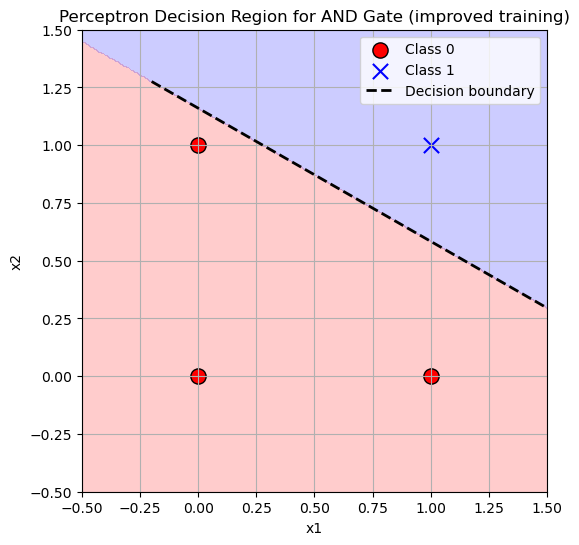

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# AND gate data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# Hyperparameters
lr = 0.1
epochs = 100
rng = np.random.RandomState(42)

# Random small initialization (better than all zeros)
weights = rng.normal(scale=0.1, size=X.shape[1])
bias = 0.0

def predict_point(x, w, b):
    z = np.dot(x, w) + b
    return 1 if z >= 0 else 0

# Train with shuffling
for epoch in range(epochs):
    indices = np.random.permutation(len(X))
    for i in indices:
        z = np.dot(X[i], weights) + bias
        y_pred = 1 if z >= 0 else 0
        update = lr * (y[i] - y_pred)
        # weight update
        weights += update * X[i]
        bias += update

print("Final weights:", weights)
print("Final bias:", bias)

# -------------- Visualization: decision region --------------
# Create a grid and classify each point
xx = np.linspace(-0.5, 1.5, 300)
yy = np.linspace(-0.5, 1.5, 300)
XX, YY = np.meshgrid(xx, yy)
grid = np.c_[XX.ravel(), YY.ravel()]

# vectorized prediction on grid
Z = np.dot(grid, weights) + bias
Z = (Z >= 0).astype(int)
Z = Z.reshape(XX.shape)

plt.figure(figsize=(6,6))
# plot decision regions
plt.contourf(XX, YY, Z, alpha=0.2, levels=[-0.1, 0.5, 1.1], colors=['red','blue'])

# plot training points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i,0], X[i,1], color='red', edgecolor='k', s=120, label='Class 0' if i == 0 else "")
    else:
        plt.scatter(X[i,0], X[i,1], color='blue', marker='x', s=120, label='Class 1')

# Also plot the boundary line safely
if abs(weights[1]) > 1e-8:
    x_vals = np.array([-0.2, 1.5])
    y_vals = -(weights[0] * x_vals + bias) / weights[1]
    plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Decision boundary')
else:
    # vertical line at x = -b/w0
    x_vert = -bias / weights[0]
    plt.axvline(x=x_vert, linestyle='--', color='k', linewidth=2, label='Decision boundary')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Region for AND Gate (improved training)")
plt.legend()
plt.grid(True)
plt.show()


Weights: [0.1 0.1]
Bias: -0.1
Predictions: [0 1 1 1]


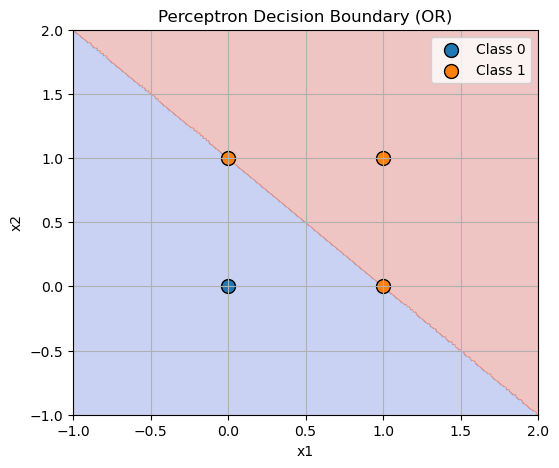

In [ ]:
# GFG - https://www.geeksforgeeks.org/deep-learning/what-is-perceptron-the-simplest-artificial-neural-network/

import numpy as np
import matplotlib.pyplot as plt

X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([0, 1, 1, 1])

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors_per_epoch = []
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else 0
                update = self.lr * (target - y_pred)
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0)
            self.errors_per_epoch.append(errors)


p_or = Perceptron(learning_rate=0.1, epochs=20)
p_or.fit(X_or, y_or)

print("Weights:", p_or.weights)
print("Bias:", p_or.bias)
print("Predictions:", p_or.predict(X_or))

def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    for label in np.unique(y):
        pts = X[y == label]
        plt.scatter(pts[:, 0], pts[:, 1],
                    s=100, edgecolor='black',
                    label=f"Class {label}")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_decision_boundary(X_or, y_or, p_or, "Perceptron Decision Boundary (OR)")

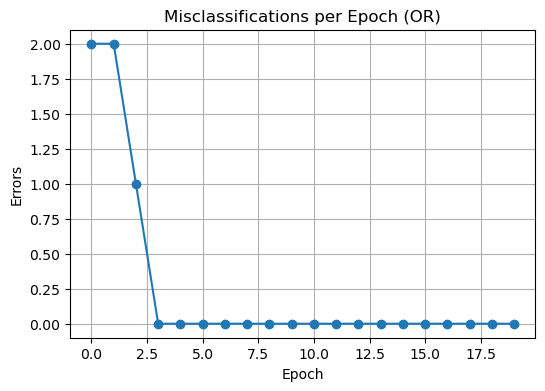

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(p_or.errors_per_epoch, marker='o')
plt.title("Misclassifications per Epoch (OR)")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.grid(True)
plt.show()